In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats


In [ ]:
# Chargement du fichier et affichage des 20 premières lignes pour explorer les données.

df = pd.read_csv("AVITO1.csv")
df.head(20)

,Ville,Secteur,Marque,Modèle,Année-Modèle,Kilométrage,Type de carburant,Puissance fiscale,Boite de vitesses,Nombre de portes,...,Caméra de recul,Vitres électriques,ABS,ESP,Régulateur de vitesse,Limiteur de vitesse,CD/MP3/Bluetooth,Ordinateur de bord,Verrouillage centralisé à distance,Prix
0,Temara,Massira 2,Fiat,Punto,2007,200 000 - 249 999,Diesel,5,Manuelle,5.0,...,False,False,True,False,False,False,True,False,False,60000
1,Temara,NaN,Dacia,Dokker Van,2013,400 000 - 449 999,Diesel,6,Manuelle,3.0,...,False,False,False,False,False,False,False,False,False,70000
2,Casablanca,NaN,Dacia,Dokker,2014,160 000 - 169 999,Diesel,6,Manuelle,5.0,...,False,False,False,False,False,False,False,False,False,90000
3,Casablanca,NaN,Volkswagen,Touareg,2005,0 - 4 999,Diesel,10,Automatique,5.0,...,False,False,False,False,False,False,False,False,False,90000
4,Dakhla,NaN,Toyota,Prado,2007,200 000 - 249 999,Diesel,12,Manuelle,5.0,...,False,False,True,False,False,False,True,False,False,97000
5,Khouribga,Toute la ville,Volkswagen,Tiguan,2014,180 000 - 189 999,Diesel,8,Automatique,5.0,...,False,False,True,True,False,False,True,False,False,243500
6,Meknès,Autre secteur,Peugeot,308,2009,200 000 - 249 999,Diesel,6,Manuelle,5.0,...,False,False,True,True,False,False,True,False,False,85000
7,Casablanca,NaN,Renault,Clio,2014,75 000 - 79 999,Diesel,6,Manuelle,5.0,...,False,False,True,True,False,False,True,False,False,93000
8,Mohammedia,NaN,Peugeot,208,2021,10 000 - 14 999,Diesel,6,Manuelle,5.0,...,False,False,True,True,False,False,True,False,False,164000
9,Fquih Ben Saleh,NaN,Volkswagen,GOLF 7,2013,120 000 - 129 999,Diesel,8,Automatique,5.0,...,False,False,True,True,False,False,True,False,False,198000


In [ ]:
# Affiche le nombre de valeurs manquantes dans chaque colonne du dataset.
df.isnull().sum()

Ville                                    0
Secteur                               5966
Marque                                   0
Modèle                                   0
Année-Modèle                             0
Kilométrage                              0
Type de carburant                        0
Puissance fiscale                        0
Boite de vitesses                        0
Nombre de portes                      2530
Origine                               2955
Première main                         3319
État                                  3480
Jantes aluminium                         0
Airbags                                  0
Climatisation                            0
Système de navigation/GPS                0
Toit ouvrant                             0
Sièges cuir                              0
Radar de recul                           0
Caméra de recul                          0
Vitres électriques                       0
ABS                                      0
ESP        

In [ ]:
# Remplacement des valeurs manquantes par "Unknown" dans plusieurs colonnes.
df["Secteur"] = df["Secteur"].fillna("Unknown")
df["Origine"] = df["Origine"].fillna("Unknown")
df["Première main"] = df["Première main"].fillna("Unknown")
df["État"] = df["État"].fillna("Unknown")

In [ ]:
# Remplacement des valeurs manquantes dans la colonne "Nombre de portes" par la médiane.
df["Nombre de portes"].fillna(df["Nombre de portes"].median(), inplace=True)

C:\Users\lenovo\AppData\Local\Temp\ipykernel_4532\4251223084.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["Nombre de portes"].fillna(df["Nombre de portes"].median(), inplace=True)


In [91]:
df.isnull().sum()

Ville                                 0
Secteur                               0
Marque                                0
Modèle                                0
Année-Modèle                          0
Kilométrage                           0
Type de carburant                     0
Puissance fiscale                     0
Boite de vitesses                     0
Nombre de portes                      0
Origine                               0
Première main                         0
État                                  0
Jantes aluminium                      0
Airbags                               0
Climatisation                         0
Système de navigation/GPS             0
Toit ouvrant                          0
Sièges cuir                           0
Radar de recul                        0
Caméra de recul                       0
Vitres électriques                    0
ABS                                   0
ESP                                   0
Régulateur de vitesse                 0


In [ ]:
# Affiche le nombre de lignes dupliquées dans le dataset.
df.duplicated().sum()

np.int64(0)

In [ ]:
# Suppression des doublons dans les données.
df = df.drop_duplicates()

In [93]:
# Affiche la taille du dataset (nombre de lignes et de colonnes).
print(df.shape)

(9099, 30)


In [ ]:
# Affiche les informations du dataset.
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 9099 entries, 0 to 9103
Data columns (total 30 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   Ville                               9099 non-null   object 
 1   Secteur                             9099 non-null   object 
 2   Marque                              9099 non-null   object 
 3   Modèle                              9099 non-null   object 
 4   Année-Modèle                        9099 non-null   int64  
 5   Kilométrage                         9099 non-null   object 
 6   Type de carburant                   9099 non-null   object 
 7   Puissance fiscale                   9099 non-null   int64  
 8   Boite de vitesses                   9099 non-null   object 
 9   Nombre de portes                    9099 non-null   float64
 10  Origine                             9099 non-null   object 
 11  Première main                       9099 non-nul

In [ ]:
# Conversion de la colonne "Nombre de portes" en type entier.
df["Nombre de portes"] = df["Nombre de portes"].astype(int)

In [66]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 9099 entries, 0 to 9103
Data columns (total 30 columns):
 #   Column                              Non-Null Count  Dtype 
---  ------                              --------------  ----- 
 0   Ville                               9099 non-null   object
 1   Secteur                             9099 non-null   object
 2   Marque                              9099 non-null   object
 3   Modèle                              9099 non-null   object
 4   Année-Modèle                        9099 non-null   int64 
 5   Kilométrage                         9099 non-null   object
 6   Type de carburant                   9099 non-null   object
 7   Puissance fiscale                   9099 non-null   int64 
 8   Boite de vitesses                   9099 non-null   object
 9   Nombre de portes                    9099 non-null   int64 
 10  Origine                             9099 non-null   object
 11  Première main                       9099 non-null   object
 1

# Analyse Univariée

In [ ]:
# Affiche les statistiques descriptives des colonnes numériques du dataset.
df.describe()

,Année-Modèle,Puissance fiscale,Nombre de portes,Prix
count,9099.000000,9099.000000,9099.000000,9099.000000
mean,2011.890867,7.216397,4.930322,118262.161007
std,5.446422,1.597182,0.366764,53060.168989
min,1990.000000,5.000000,3.000000,60000.000000
25%,2008.000000,6.000000,5.000000,76000.000000
50%,2013.000000,7.000000,5.000000,102000.000000
75%,2016.000000,8.000000,5.000000,143000.000000
max,2022.000000,14.000000,5.000000,243500.000000


Text(0.5, 1.0, 'Distribution des boîtes de vitesses')

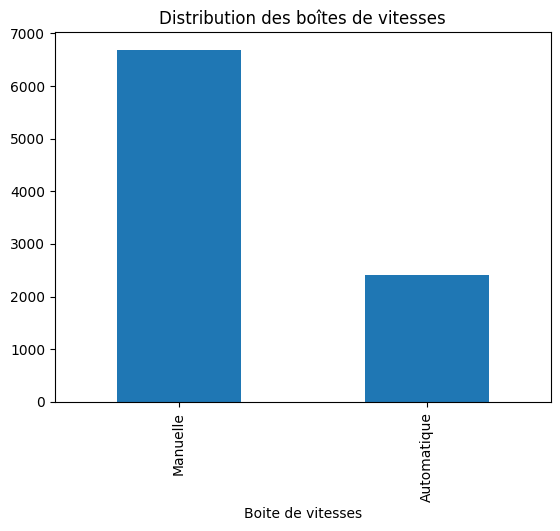

In [68]:
df["Boite de vitesses"].value_counts().plot(kind="bar")
plt.title('Distribution des boîtes de vitesses')


## Le graphique montre que les voitures manuelles sont plus nombreuses que les voitures automatiques dans le dataset.

Text(0.5, 1.0, 'Type de carburant')

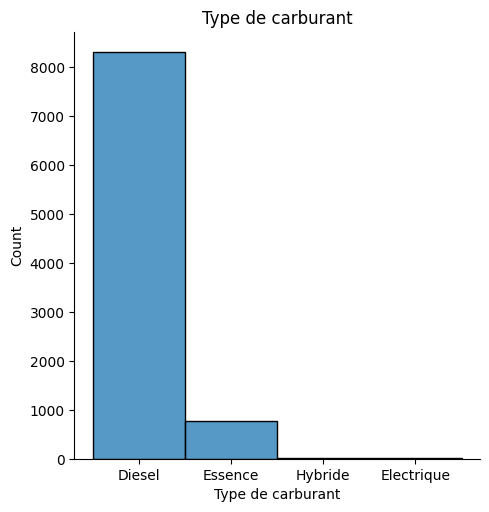

In [69]:
sns.displot(data=df,x=df['Type de carburant'])
plt.title('Type de carburant')

## Le graphique montre que le diesel est le carburant le plus utilisé dans le dataset, suivi de loin par l’essence. Les voitures hybrides et électriques sont très peu représentées.

Text(0.5, 1.0, 'ABS')

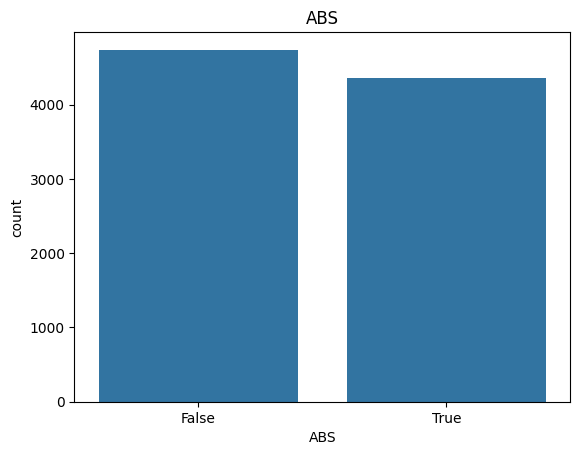

In [70]:
sns.countplot(data=df, x='ABS')
plt.title('ABS')

## Le graphique montre que les véhicules avec ABS et sans ABS sont presque en nombre égal, avec une légère différence entre les deux catégories.

Text(0.5, 1.0, 'Top 10 marques')

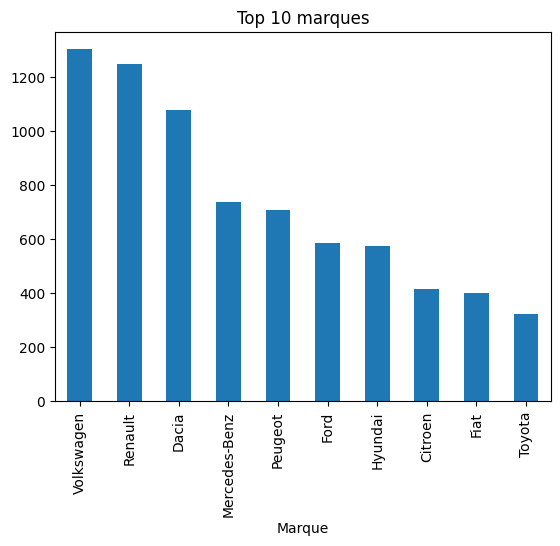

In [99]:
df['Marque'].value_counts().head(10).plot(kind='bar')

plt.title('Top 10 marques')

## Le graphique montre les 10 marques de voitures les plus présentes dans le dataset. Volkswagen, Renault et Dacia sont les marques les plus fréquentes, tandis que les autres marques ont des effectifs plus faibles.

Text(0, 0.5, "Nombre d'annonces")

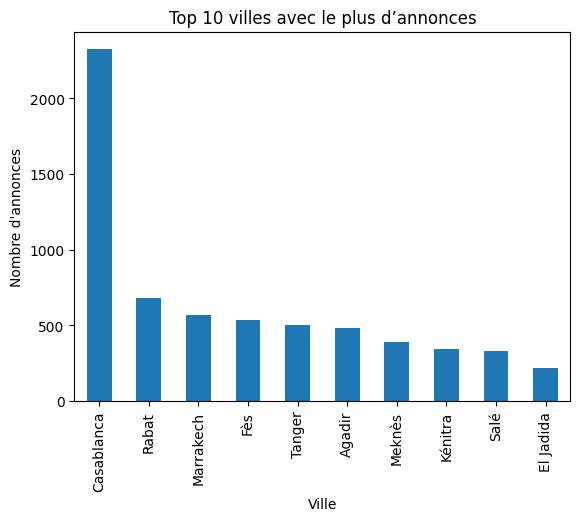

In [98]:

df['Ville'].value_counts().head(10).plot(kind='bar')

plt.title('Top 10 villes avec le plus d’annonces')
plt.xlabel('Ville')
plt.ylabel("Nombre d'annonces")

## Ce graphique montre les 10 villes ayant le plus d’annonces dans le dataset. Casablanca est la ville la plus dominante, suivie de Rabat et Marrakech, tandis que les autres villes ont un nombre d’annonces plus faible.

In [ ]:
# Affiche les statistiques principales des prix (moyenne, min, max, quartiles).
df['Prix'].describe()

count      9099.000000
mean     118262.161007
std       53060.168989
min       60000.000000
25%       76000.000000
50%      102000.000000
75%      143000.000000
max      243500.000000
Name: Prix, dtype: float64

(array([ 50000.,  75000., 100000., 125000., 150000., 175000., 200000.,
        225000., 250000., 275000.]),
 [Text(50000.0, 0, '50000'),
  Text(75000.0, 0, '75000'),
  Text(100000.0, 0, '100000'),
  Text(125000.0, 0, '125000'),
  Text(150000.0, 0, '150000'),
  Text(175000.0, 0, '175000'),
  Text(200000.0, 0, '200000'),
  Text(225000.0, 0, '225000'),
  Text(250000.0, 0, '250000'),
  Text(275000.0, 0, '275000')])

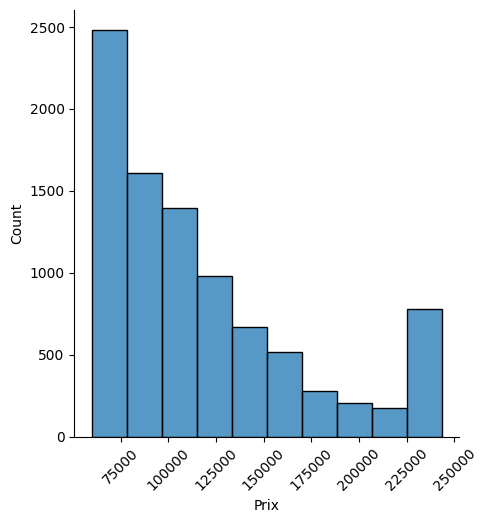

In [113]:
sns.displot(data=df, x='Prix',bins=10)
plt.xticks(rotation=45)

## Le graphique montre que la plupart des voitures ont des prix bas ou moyens, tandis que les voitures très chères sont moins nombreuses.

# Analyse Multi-Variée

Text(0.5, 1.0, 'Marque vs Boite de vitesses')

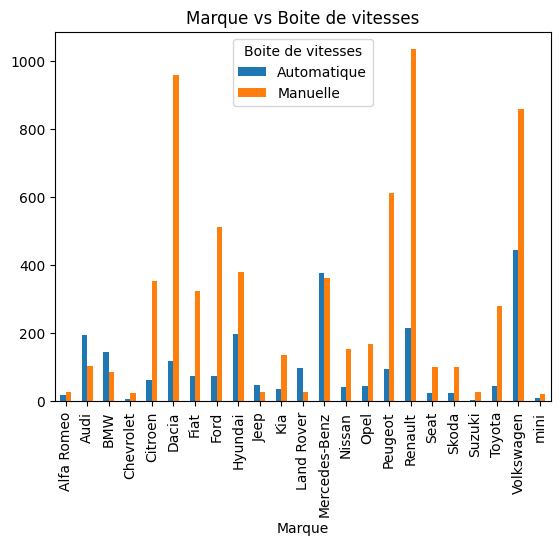

In [71]:
ct = pd.crosstab(df['Marque'], df['Boite de vitesses'])

ct.plot(kind='bar' )
plt.title('Marque vs Boite de vitesses')

## Le graphique montre que les voitures à boîte manuelle sont plus nombreuses que les voitures automatiques pour la plupart des marques. Les marques haut de gamme comme Mercedes-Benz, BMW et Audi présentent davantage de voitures automatiques.

Text(0.5, 1.0, 'Prix moyen selon le type de boîte de vitesses')

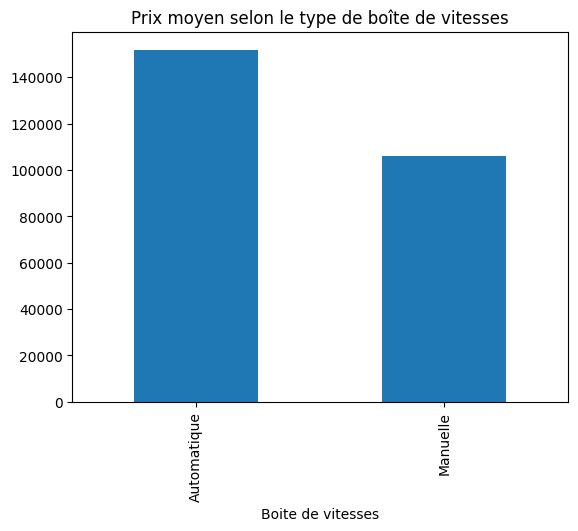

In [97]:
df.groupby('Boite de vitesses')['Prix'].mean().plot(kind='bar')
plt.title("Prix moyen selon le type de boîte de vitesses")


## Le graphique montre que les voitures automatiques ont un prix moyen plus élevé que les voitures manuelles. Cela indique que le type de boîte de vitesses influence le prix des véhicules.

Text(0.5, 1.0, 'Boîte de vitesses vs type de carburant')

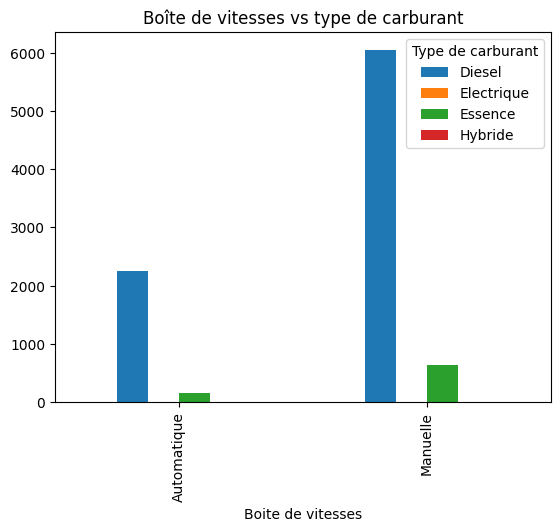

In [108]:
pd.crosstab(df['Boite de vitesses'], df['Type de carburant']).plot(kind='bar')
plt.title("Boîte de vitesses vs type de carburant")

## Le graphique montre que les voitures diesel sont les plus nombreuses, qu'elles soient automatiques ou manuelles. Les voitures électriques et hybrides sont très peu représentées dans le dataset.

In [88]:
auto = df[df['Boite de vitesses'] == 'Automatique']['Prix']
manual = df[df['Boite de vitesses'] == 'Manuelle']['Prix']

In [87]:
from scipy.stats import ttest_ind

t_stat, p_value = ttest_ind(auto, manual)

print("T-statistic:", t_stat)
print("P-value:", p_value)

T-statistic: 39.261369456500745
P-value: 0.0


In [51]:
print("Prix moyen automatique:", auto.mean())
print("Prix moyen manuelle:", manual.mean())

Prix moyen automatique: 151870.9602319801
Prix moyen manuelle: 106125.78982797307


### Le test t de Student a été utilisé pour comparer les prix des voitures automatiques et manuelles. Les résultats montrent une différence statistiquement significative (p-value ≈ 0), ce qui indique que le type de boîte de vitesses influence le prix des véhicules.
##### En moyenne, les voitures automatiques sont plus chères (151 870) que les voitures manuelles (106 126).

In [109]:
from scipy.stats import f_oneway
diesel = df[df['Type de carburant'] == 'Diesel']['Prix']
essence = df[df['Type de carburant'] == 'Essence']['Prix']
electrique = df[df['Type de carburant'] == 'Electrique']['Prix']

f_stat, p_value = f_oneway(diesel, essence, electrique)

print("F-statistic:", f_stat)
print("P-value:", p_value)

F-statistic: 127.3879462654322
P-value: 2.7367916569843545e-55


### Le test ANOVA a été utilisé pour comparer les prix des voitures selon le type de carburant (Diesel, Essence, Électrique). Les résultats montrent une différence statistiquement significative entre les groupes (p-value ≈ 0), ce qui indique que le type de carburant influence le prix des véhicules.

#### En résumé, il existe une variation significative des prix en fonction du type de carburant.

In [115]:
df.to_csv("Avito_data.csv", index=False)